In [1]:
import itertools
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import torch.distributions as D
import numpy as np
from numpy.random import default_rng
import pymc as pm
from scipy.stats import vonmises
from scipy.special import i0

from insilico_stimuli.stimuli import GaborSet, CenterSurround

seed = 42
rng = default_rng(seed=seed)
torch.manual_seed(seed=seed)
EPSILON = 1e-12
mpl.style.use("seaborn")
sns.set_palette("colorblind")
sns.set_context("paper")
sns.set_style("darkgrid")
mpl.style.use("seaborn")

/usr/local/lib/python3.8/dist-packages/pkg_resources/__init__.py:123: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/usr/lib/python3/dist-packages/requests/__init__.py:89: RequestsDependencyWarning: urllib3 (1.26.12) or chardet (3.0.4) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "


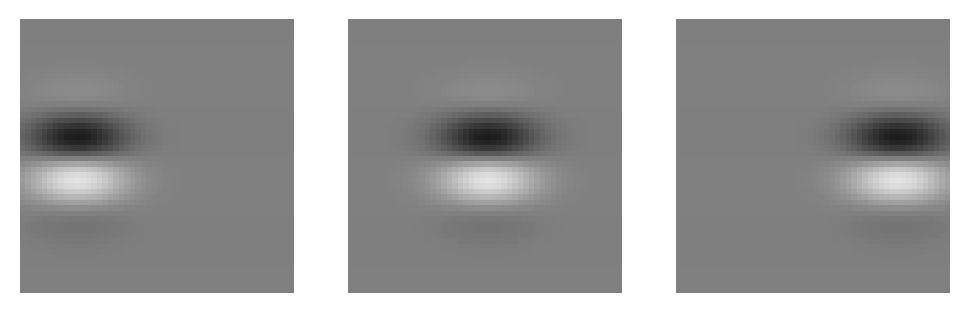

In [2]:
gabor_locations = [(10, 25), (25, 25), (40, 25)]
gabor_params = {
    "canvas_size": [50, 50],
    "sizes": [25],
    "spatial_frequencies": [1 / 20],
    "contrasts": [1.0],
    "grey_levels": [0.0],
    "eccentricities": [0.0],
    "locations": gabor_locations,
    "orientations": [np.pi / 2],
    "phases": [np.pi / 2],
    "relative_sf": False,
}

horizontal_gabor_set = GaborSet(**gabor_params)
horizontal_gabors = horizontal_gabor_set.images()
fig, axs = plt.subplots(nrows=1, ncols=3, dpi=200)
for idx, ax in enumerate(axs.ravel()):
    gabor = horizontal_gabors[idx]
    ax.imshow(gabor, cmap="gray", vmin=-1, vmax=1)
    ax.axis("off")

(-0.5, 49.5, 49.5, -0.5)

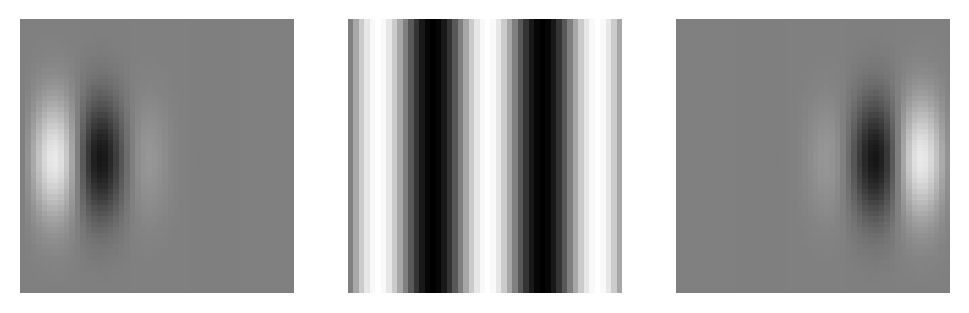

In [3]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1 / 20],
    "phases_center": [np.pi / 2 + 2 * np.pi * 1 / 20 * (25 - 10)],
    "phases_surround": [np.pi / 2 + 2 * np.pi * 1 / 20 * (25 - 10)],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [0.0],
    "orientations_surround": [0.0],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [30 / 4 / 50],
    "sizes_surround": [30 / 4 / 50],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

full_field_vertical_gabor_set = CenterSurround(**center_surround_params)
full_field_vertical_gabor = full_field_vertical_gabor_set.images()[0]

U, V = np.meshgrid(np.arange(50), np.arange(50))
XX = np.stack((U, V), axis=-1)
gauss_mask_right = np.exp(
    -np.sum((XX - np.array([40, 25])) ** 2, axis=-1) / (30 / 4) ** 2 / 2
)
gauss_mask_left = np.exp(
    -np.sum((XX - np.array([10, 25])) ** 2, axis=-1) / (30 / 4) ** 2 / 2
)

vertical_gabor_right = full_field_vertical_gabor * gauss_mask_right
vertical_gabor_left = full_field_vertical_gabor * gauss_mask_left

fig, axs = plt.subplots(nrows=1, ncols=3, dpi=200)
axs[0].imshow(vertical_gabor_left, cmap="gray", vmin=-1, vmax=1)
axs[0].axis("off")
axs[1].imshow(full_field_vertical_gabor, cmap="gray", vmin=-1, vmax=1)
axs[1].axis("off")
axs[2].imshow(vertical_gabor_right, cmap="gray", vmin=-1, vmax=1)
axs[2].axis("off")
plt.axis("off")

(-0.5, 49.5, 49.5, -0.5)

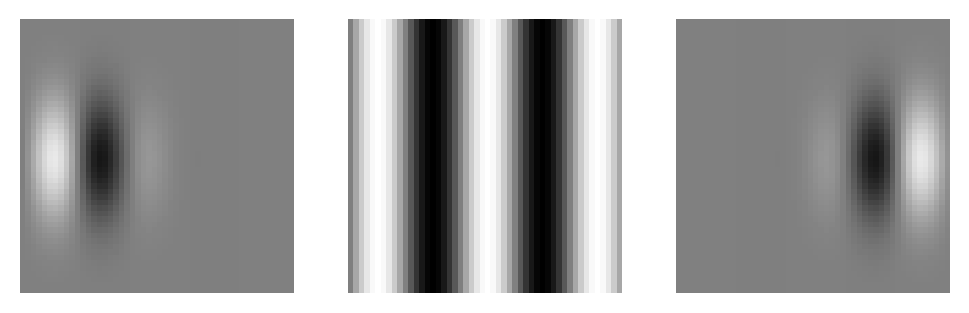

In [6]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1 / 20],
    "phases_center": [np.pi / 2 + 2 * np.pi * 1 / 20 * (25 + 10)],
    "phases_surround": [np.pi / 2 + 2 * np.pi * 1 / 20 * (25 + 10)],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [0.0],
    "orientations_surround": [0.0],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [30 / 4 / 50],
    "sizes_surround": [30 / 4 / 50],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

full_field_vertical_gabor_set = CenterSurround(**center_surround_params)
full_field_vertical_gabor = full_field_vertical_gabor_set.images()[0]

U, V = np.meshgrid(np.arange(50), np.arange(50))
XX = np.stack((U, V), axis=-1)
gauss_mask_right = np.exp(
    -np.sum((XX - np.array([40, 25])) ** 2, axis=-1) / (30 / 4) ** 2 / 2
)
gauss_mask_left = np.exp(
    -np.sum((XX - np.array([10, 25])) ** 2, axis=-1) / (30 / 4) ** 2 / 2
)

vertical_gabor_right = full_field_vertical_gabor * gauss_mask_right
vertical_gabor_left = full_field_vertical_gabor * gauss_mask_left

fig, axs = plt.subplots(nrows=1, ncols=3, dpi=200)
axs[0].imshow(vertical_gabor_left, cmap="gray", vmin=-1, vmax=1)
axs[0].axis("off")
axs[1].imshow(full_field_vertical_gabor, cmap="gray", vmin=-1, vmax=1)
axs[1].axis("off")
axs[2].imshow(vertical_gabor_right, cmap="gray", vmin=-1, vmax=1)
axs[2].axis("off")
plt.axis("off")

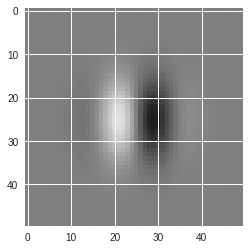

In [4]:
gabor_locations = [(25, 25)]
gabor_params = {
    "canvas_size": [50, 50],
    "sizes": [25],
    "spatial_frequencies": [1 / 20],
    "contrasts": [1.0],
    "grey_levels": [0.0],
    "eccentricities": [0.0],
    "locations": gabor_locations,
    "orientations": [0],
    "phases": [np.pi / 2],
    "relative_sf": False,
}

vertical_gabor_set = GaborSet(**gabor_params)
vertical_gabor_center = vertical_gabor_set.images()[0]
plt.imshow(vertical_gabor_center, cmap="gray", vmin=-1, vmax=1)

In [5]:
gabor_filters = np.concatenate(
    [
        horizontal_gabors,
        np.array([vertical_gabor_left, vertical_gabor_right, vertical_gabor_center]),
    ],
    axis=0,
)

In [7]:
# np.save("/src/project/computed/gaabor_filters_overlapping_with_vertical_center.npy", gabor_filters)

In [6]:
# np.save("/src/project/computed/gaabor_filters_overlapping.npy", gabor_filters)

In [8]:
# np.save("/src/project/computed/gaabor_filters_overlapping_with_vertical_center_orientations.npy", np.array([np.pi/2, np.pi/2, np.pi/2, 0, 0, 0]))

(-0.5, 49.5, 49.5, -0.5)

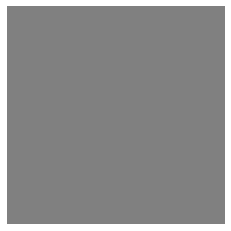

In [6]:
blank_stimuli_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1 / 20],
    "phases_center": [np.pi / 2],
    "phases_surround": [np.pi / 2],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi / 2],
    "orientations_surround": [np.pi / 2],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [30 / 4 / 50],
    "sizes_surround": [30 / 4 / 50],
    "contrasts_center": [0],
    "contrasts_surround": [0],
}

blank_stimulus_set = CenterSurround(**blank_stimuli_params)
blank_stimulus = blank_stimulus_set.images()[0]

plt.imshow(blank_stimulus, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

(-0.5, 49.5, 49.5, -0.5)

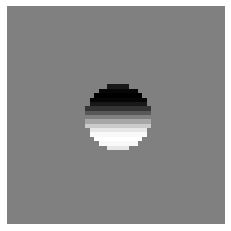

In [7]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1 / 20],
    "phases_center": [np.pi / 2],
    "phases_surround": [np.pi / 2 + 2 * np.pi * 1 / 20 * (25 - 10)],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi / 2],
    "orientations_surround": [0.0],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [30 / 4 / 50],
    "sizes_surround": [30 / 4 / 50],
    "contrasts_center": [1.0],
    "contrasts_surround": [0],
}

center_only_set = CenterSurround(**center_surround_params)
center_only_stimulus = center_only_set.images()[0]

plt.imshow(center_only_stimulus, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

(-0.5, 49.5, 49.5, -0.5)

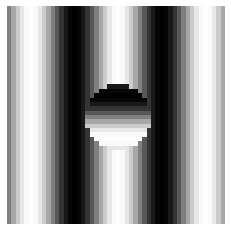

In [8]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1 / 20],
    "phases_center": [np.pi / 2],
    "phases_surround": [np.pi / 2 + 2 * np.pi * 1 / 20 * (25 - 10)],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi / 2],
    "orientations_surround": [0.0],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [30 / 4 / 50],
    "sizes_surround": [30 / 4 / 50],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

incongruent_surround_set = CenterSurround(**center_surround_params)
incongruent_surround_stimulus = incongruent_surround_set.images()[0]

plt.imshow(incongruent_surround_stimulus, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

(-0.5, 49.5, 49.5, -0.5)

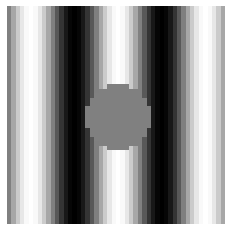

In [9]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1 / 20],
    "phases_center": [np.pi / 2],
    "phases_surround": [np.pi / 2 + 2 * np.pi * 1 / 20 * (25 - 10)],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi / 2],
    "orientations_surround": [0.0],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [30 / 4 / 50],
    "sizes_surround": [30 / 4 / 50],
    "contrasts_center": [0],
    "contrasts_surround": [1.0],
}

incongruent_no_center_set = CenterSurround(**center_surround_params)
incongruent_no_center_stimulus = incongruent_no_center_set.images()[0]

plt.imshow(incongruent_no_center_stimulus, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

(-0.5, 49.5, 49.5, -0.5)

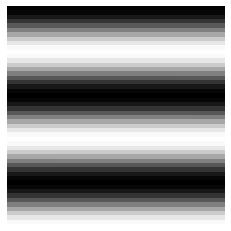

In [10]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1 / 20],
    "phases_center": [np.pi / 2],
    "phases_surround": [np.pi / 2],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi / 2],
    "orientations_surround": [np.pi / 2],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [30 / 4 / 50],
    "sizes_surround": [30 / 4 / 50],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

congruent_surround_set = CenterSurround(**center_surround_params)
congruent_surround_stimulus = congruent_surround_set.images()[0]

plt.imshow(congruent_surround_stimulus, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

(-0.5, 49.5, 49.5, -0.5)

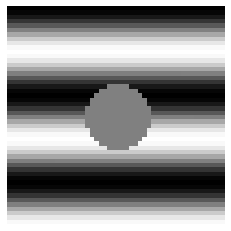

In [11]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1 / 20],
    "phases_center": [np.pi / 2],
    "phases_surround": [np.pi / 2],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi / 2],
    "orientations_surround": [np.pi / 2],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [30 / 4 / 50],
    "sizes_surround": [30 / 4 / 50],
    "contrasts_center": [0],
    "contrasts_surround": [1.0],
}

congruent_no_center_set = CenterSurround(**center_surround_params)
congruent_no_center_stimulus = congruent_no_center_set.images()[0]

plt.imshow(congruent_no_center_stimulus, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

In [13]:
# stimuli = np.array([center_only_stimulus, incongruent_surround_stimulus, congruent_surround_stimulus])
# np.save("/src/project/computed/gabor_filters_overlapping_stimuli.npy", stimuli)

In [ ]:
# np.save("/src/project/computed/gabor_filters_overlapping_stimuli.npy", stimuli)

In [ ]:
# np.save("/src/project/computed/gabor_filters_overlapping_orientations.npy", np.array([np.pi/2, np.pi/2, np.pi/2, 0., 0.]))

In [ ]:
# new_stimuli = np.array([blank_stimulus, center_only_stimulus, incongruent_surround_stimulus, congruent_surround_stimulus])
# np.save("/src/project/computed/gabor_filters_overlapping_stimuli.npy", stimuli)

In [9]:
all_stimuli = np.array(
    [
        blank_stimulus,
        center_only_stimulus,
        incongruent_surround_stimulus,
        incongruent_no_center_stimulus,
        congruent_surround_stimulus,
        congruent_no_center_stimulus,
    ]
)

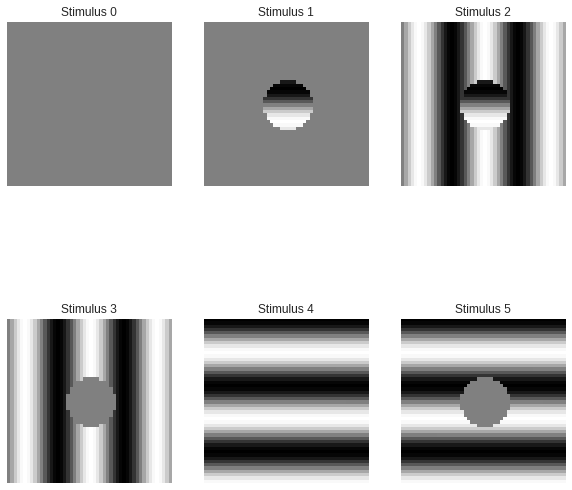

In [10]:
# display all stimuli
fig, axes = plt.subplots(2, 3, figsize=(10, 10))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(all_stimuli[i], cmap="gray", vmin=-1, vmax=1)
    ax.axis("off")
    ax.set_title(f"Stimulus {i}")

In [12]:
np.std(congruent_surround_stimulus)

0.7068238818828917

In [14]:
np.std(center_only_stimulus)

0.19858516555246467

(-0.5, 49.5, 49.5, -0.5)

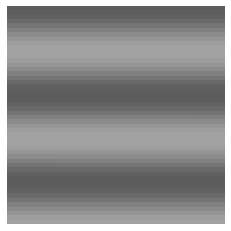

In [13]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1 / 20],
    "phases_center": [np.pi / 2],
    "phases_surround": [np.pi / 2],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi / 2],
    "orientations_surround": [np.pi / 2],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [30 / 4 / 50],
    "sizes_surround": [30 / 4 / 50],
    "contrasts_center": [
        np.std(center_only_stimulus) / np.std(congruent_surround_stimulus)
    ],
    "contrasts_surround": [
        np.std(center_only_stimulus) / np.std(congruent_surround_stimulus)
    ],
}

contrast_matched_congruent_set = CenterSurround(**center_surround_params)
contrast_matched_congruent_stimulus = contrast_matched_congruent_set.images()[0]

plt.imshow(contrast_matched_congruent_stimulus, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

In [15]:
np.std(contrast_matched_congruent_stimulus)

0.1985851655524647

In [15]:
# all_stimuli =  np.array([blank_stimulus, center_only_stimulus, incongruent_surround_stimulus, incongruent_no_center_stimulus, congruent_surround_stimulus, congruent_no_center_stimulus, contrast_matched_congruent_stimulus])
# np.save("/src/project/computed/gabor_filters_overlapping_stimuli_all.npy", all_stimuli)

(-0.5, 49.5, 49.5, -0.5)

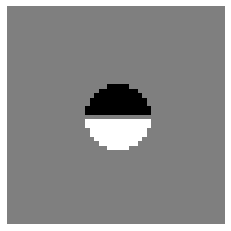

In [17]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1 / 20],
    "phases_center": [np.pi / 2],
    "phases_surround": [0],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi / 2],
    "orientations_surround": [0.0],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [30 / 4 / 50],
    "sizes_surround": [30 / 4 / 50],
    "contrasts_center": [
        np.std(congruent_surround_stimulus) / np.std(center_only_stimulus)
    ],
    "contrasts_surround": [0],
}

center_only_set_contrast_matched = CenterSurround(**center_surround_params)
center_only_stimulus_contrast_matched = center_only_set_contrast_matched.images()[0]

plt.imshow(center_only_stimulus_contrast_matched, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

In [18]:
all_stimuli = np.array(
    [
        blank_stimulus,
        center_only_stimulus,
        incongruent_surround_stimulus,
        incongruent_no_center_stimulus,
        congruent_surround_stimulus,
        congruent_no_center_stimulus,
        center_only_stimulus_contrast_matched,
    ]
)
np.save("/src/project/computed/gabor_filters_overlapping_stimuli_all.npy", all_stimuli)